# Прогнозирование спроса на товары

Задача регрессии на временных рядах: предсказать ежедневный спрос (`demand`)
по каждому товару. Ключевое решение — разбиение train/test **по дате**, чтобы не было утечки будущего. Сравниваю наивные бейзлайны, линейную
регрессию и нейросеть (MLP) по MAE и RMSE.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Загрузка данных и формирование признаков

Сортирую по паре «товар–дата», добавляю лаги (`lag_1`, `lag_7`) и календарные
признаки (день недели, месяц). Товары кодирую через one-hot.

In [5]:
data_path = "/content/synthetic_retail_demand_dataset.csv"

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["item_id", "date"]).reset_index(drop=True)
df["dayofweek"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["lag_1"] = df.groupby("item_id")["demand"].shift(1)
df["lag_7"] = df.groupby("item_id")["demand"].shift(7)
df = df.dropna().reset_index(drop=True)
df = pd.get_dummies(df, columns=["item_id"], drop_first=True)
df.head()


,date,item_name,category,brand,price,competitor_price,promo,promo_type,discount_depth,holiday,...,item_id_item_009,item_id_item_010,item_id_item_011,item_id_item_012,item_id_item_013,item_id_item_014,item_id_item_015,item_id_item_016,item_id_item_017,item_id_item_018
0,2023-01-08,Milk 1L,Dairy,FreshFarm,217.32,226.79,0,none,0.0,0,...,False,False,False,False,False,False,False,False,False,False
1,2023-01-09,Milk 1L,Dairy,FreshFarm,216.82,214.84,0,none,0.0,0,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-10,Milk 1L,Dairy,FreshFarm,217.83,209.67,0,none,0.0,0,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-11,Milk 1L,Dairy,FreshFarm,218.04,208.57,0,none,0.0,0,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-12,Milk 1L,Dairy,FreshFarm,216.41,225.00,0,none,0.0,0,...,False,False,False,False,False,False,False,False,False,False


## Разбиение по времени

Всё до 2024-10-01 — в train, остальное — в test. Модель учится только на прошлом.

In [6]:
split_date = "2024-10-01"

train = df[df["date"] < split_date].copy()
test = df[df["date"] >= split_date].copy()

features = [col for col in df.columns if col not in ["date", "demand", "item_name", "category", "brand", "promo_type"]]

X_train = train[features]
y_train = train["demand"]

X_test = test[features]
y_test = test["demand"]

X_train.shape, X_test.shape


((11376, 30), (1656, 30))

## Модели

Наивный прогноз (lag_1), сезонный (lag_7), линейная регрессия и MLPRegressor.
Прогнозы обрезаю снизу по нулю — спрос не бывает отрицательным. Для MLP —
StandardScaler в Pipeline, чтобы масштабирование училось только на train.

In [7]:
naive_pred = test["lag_1"].values
seasonal_pred = test["lag_7"].values

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = np.clip(lin_model.predict(X_test), 0, None)

mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)
mlp_pred = np.clip(mlp_model.predict(X_test), 0, None)


## Сравнение по MAE и RMSE

In [8]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

results = []

for name, preds in [
    ("naive_lag_1", naive_pred),
    ("seasonal_lag_7", seasonal_pred),
    ("linear_regression", lin_pred),
    ("mlp_regressor", mlp_pred),
]:
    mae, rmse = calc_metrics(y_test, preds)
    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df


,model,MAE,RMSE
0,mlp_regressor,7.626448,9.732213
1,linear_regression,8.986007,11.366016
2,seasonal_lag_7,11.917271,16.589331
3,naive_lag_1,13.266908,17.779480


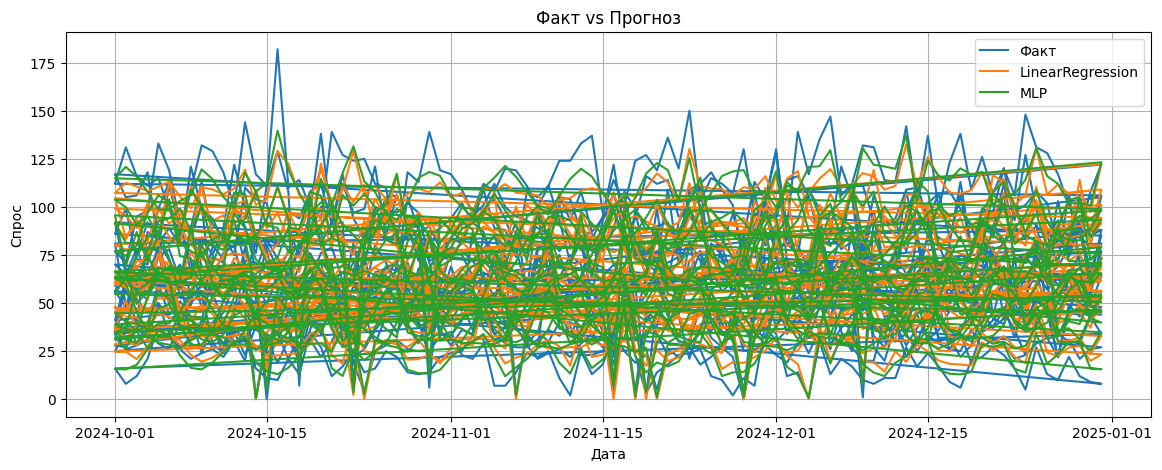

In [9]:
test_plot = test.copy()
test_plot["linear_prediction"] = lin_pred
test_plot["mlp_prediction"] = mlp_pred

plt.figure(figsize=(14, 5))
plt.plot(test_plot["date"], test_plot["demand"], label="Факт")
plt.plot(test_plot["date"], test_plot["linear_prediction"], label="LinearRegression")
plt.plot(test_plot["date"], test_plot["mlp_prediction"], label="MLP")
plt.title("Факт vs Прогноз")
plt.xlabel("Дата")
plt.ylabel("Спрос")
plt.legend()
plt.grid(True)
plt.show()
